In [1]:
import pandas as pd
import numpy as np
import keras
from keras import models
from keras import layers
from keras import optimizers
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Introduction
Recently, 1D convolutional neural network (CNN), typically used with dilated kernels, have been used with great success for audio generation and machine translation. In addition to these successes, it has long been known that small 1D convnets can offer a fast alternative to RNNs for simple tasks such as text classification and timeseries forecasting.
In this notebook, we will see how to classify time series data using 1D convnets and how to best avoid overfitting as well as ways in which hyperparameters can be tuned to improve the model's accuracy. This mini project follows two main steps: first is the data preparation to turn the dataset into an accepted form we can ingest in the model. Second is the model building and tuning to improve accuracy.
It is worth noting that classical machine learning methods could be used for time series data, but would require hand crafting features using feature engineering. Deep learning methods such as Recurrent neural nets or convolutional neural nets have shown to provide state-of-the-art results on challenging activity recognition tasks with little or no feature engineering used.
Below, I load the dataset and provide a snapshot of what I will be working with.

## Dataset Description
The Electroencephalography (EEG) dataset contains electronic brainwave signals from a EEG headset and is in temporal (timeseries) format. The main question of this study is: can we predict emotional sentiment from brainwave readings? Brainwave readings are classified into three categories: Negative, Positive and Neutral emotions.

In [3]:
# data importation
df_emotion = pd.read_csv('Data/emotions.csv')
print(df_emotion.shape)
df_emotion.head()

(2132, 2549)


,# mean_0_a,mean_1_a,mean_2_a,mean_3_a,mean_4_a,mean_d_0_a,mean_d_1_a,mean_d_2_a,mean_d_3_a,mean_d_4_a,...,fft_741_b,fft_742_b,fft_743_b,fft_744_b,fft_745_b,fft_746_b,fft_747_b,fft_748_b,fft_749_b,label
0,4.62,30.3,-356.0,15.6,26.3,1.070,0.411,-15.70,2.06,3.15,...,23.5,20.3,20.3,23.5,-215.0,280.00,-162.00,-162.00,280.00,NEGATIVE
1,28.80,33.1,32.0,25.8,22.8,6.550,1.680,2.88,3.83,-4.82,...,-23.3,-21.8,-21.8,-23.3,182.0,2.57,-31.60,-31.60,2.57,NEUTRAL
2,8.90,29.4,-416.0,16.7,23.7,79.900,3.360,90.20,89.90,2.03,...,462.0,-233.0,-233.0,462.0,-267.0,281.00,-148.00,-148.00,281.00,POSITIVE
3,14.90,31.6,-143.0,19.8,24.3,-0.584,-0.284,8.82,2.30,-1.97,...,299.0,-243.0,-243.0,299.0,132.0,-12.40,9.53,9.53,-12.40,POSITIVE
4,28.30,31.3,45.2,27.3,24.5,34.800,-5.790,3.06,41.40,5.52,...,12.0,38.1,38.1,12.0,119.0,-17.60,23.90,23.90,-17.60,NEUTRAL


Below, we visualize a barplot depicting the share of each response category in the dataset. There is equal distribution of labels, meaning that we will not need any statistical techniques suchs oversampling or undersampling to deal with imbalanceness in the labels.

Text(0.5, 1.0, 'Emotional Sentiment Class Distribution')

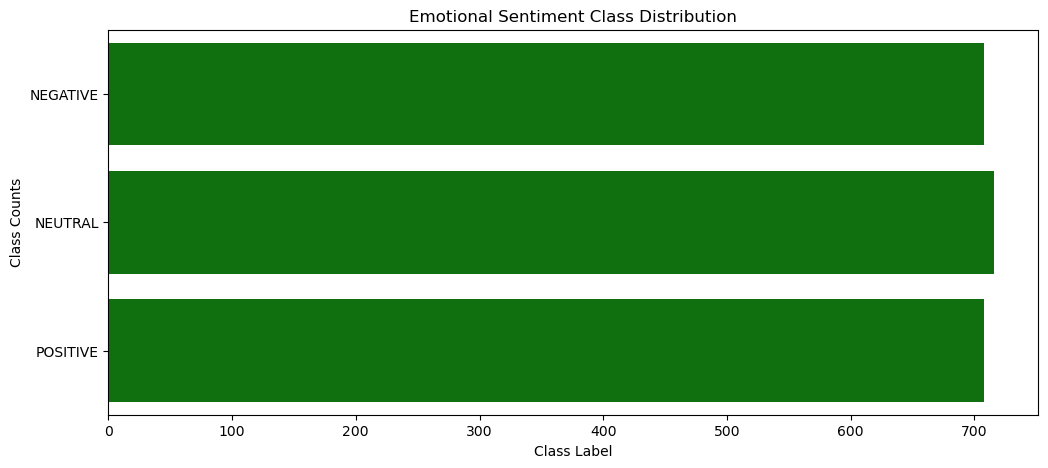

In [4]:
plt.figure(figsize=(12,5))
sns.countplot(df_emotion.label, color='g')
plt.xlabel("Class Label")
plt.ylabel("Class Counts")
plt.title("Emotional Sentiment Class Distribution")

## Preprocessing the Data
This process involves redefining the labels since they cannot remain as strings, one-hot encoding the labels, turning the whole dataset into an array using numpy, splitting the data into training and testing sets, normalizing the data (it would be problematic to feed into the neural network values that all take widely different ranges), and finally reshaping the input data. In the following code chunk, I will assign labels values from 0 to 2 to help during the one-hot encoding process.

In [6]:
# categorizing the labels
df_emotion.loc[df_emotion['label'] == 'POSITIVE', 'label'] = 0
df_emotion.loc[df_emotion['label'] == 'NEGATIVE', 'label'] = 1
df_emotion.loc[df_emotion['label'] == 'NEUTRAL', 'label'] = 2

# defining features as x and label as y
x = df_emotion.iloc[:,:-1] # selecting oth column to n-1th column
y = df_emotion.iloc[:,-1] # selecting the 'label' column
# preparing the labels: one-hot encoding array
y = to_categorical(y)
print(y)
# changing the input data into an array
x = np.array(x[:])
print(x)

[[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 ...
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
[[ 4.62e+00  3.03e+01 -3.56e+02 ... -1.62e+02 -1.62e+02  2.80e+02]
 [ 2.88e+01  3.31e+01  3.20e+01 ... -3.16e+01 -3.16e+01  2.57e+00]
 [ 8.90e+00  2.94e+01 -4.16e+02 ... -1.48e+02 -1.48e+02  2.81e+02]
 ...
 [-5.47e-01  2.83e+01 -2.59e+02 ... -1.05e+01 -1.05e+01 -1.69e+02]
 [ 1.68e+01  1.99e+01 -2.88e+02 ... -2.71e+02 -2.71e+02  5.52e+02]
 [ 2.70e+01  3.20e+01  3.18e+01 ...  2.28e+01  2.28e+01 -6.71e+00]]


Below, I split the input data and labels into training data, training label, testing data, testing label. Note that 20% of the input data was used as testing for the model validation step whereas 80% of the input data was used as training.

In [7]:
# splitting the dataset into training and testing plus respective labels
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=200)

During normalization (see below), for each feature in the input data, I substracted the mean of the feature and divided by the standard deviation so that the feature is centered around 0 and has a unit standard deviation.

In [8]:
# normalizing the dataset: i also could use StandardScalar from preprocessing
## substracting the mean with respect to each column
mean = X_train.mean(axis=0)
X_train -= mean
## dividing by the standard deviation
std = X_train.std(axis=0)
X_train /= std
## doing the same for test dataset but making sure I normalize using training dataset
X_test -= mean
X_test /= std

In keras, the 1D convnet layer takes as input a 3D array with shape (samples, timesteps, features) and returns a similarly shaped 3D array. 

In [9]:
# reshape from [samples, timesteps] into [samples, timesteps, features]
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
print(X_train.shape)
print(X_test.shape)

# validating the approach by splitting the training dataset
x_val = X_train[:500] # validation data is 500 long
partial_x_train = X_train[500:]

y_val = y_train[:500] # validation label is 500 long
partial_y_train = y_train[500:]

(1705, 2548, 1)
(427, 2548, 1)


# Model Building and Validating
## 1D convolution for sequence data
In the same way that 2D convolutions work, 1D convolutions work by extracting local 1D patches (subsequences) from sequences. It does so by recognizing local patterns in a sequence. Because the same input transformation is performed on every patch, a pattern learned at a certain position in a sequence can later be recognized at a different position, making 1D convnets **translation invariant (for temporal translations)**.

## 1D pooling for sequence data
The pooling layer works by extracting 1D patches (subsequences) from an input and outputting the maximum value (max pooling) or average value (average pooling) to reduce the length of the output of the convolutional layer to the most salient elements.

The convolutional and pooling layers are followed by a dense fully connected layer that interprets the features extracted by the convolutional part of the model. A flatten layer is used between the convolutional layers and the dense layer to reduce the feature maps to a single one-dimensional vector.

In [10]:
n_features = 1
# model definition
model = models.Sequential()
model.add(layers.Conv1D(128, kernel_size=3, activation='relu', input_shape=(X_train.shape[1],n_features)))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling1D(pool_size=(2)))
model.add(layers.Conv1D(128, kernel_size=3, activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling1D(pool_size=(2)))
model.add(layers.Flatten()) # reducing the output into 1D vector
model.add(layers.Dense(64, activation='tanh'))
model.add(layers.Dropout(0.2)) # preventing overfitting
model.add(layers.Dense(32, activation='tanh'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(3, activation='softmax')) # label categorized in 3 classes
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 2546, 128)      │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2546, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 1273, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 1271, 128)      │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1271, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 635, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 81280)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     5,201,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,255,459 (20.05 MB)

 Trainable params: 5,254,947 (20.05 MB)

 Non-trainable params: 512 (2.00 KB)

In [11]:
# Compiling the model
model.compile(optimizer='adam', # for updating the weights
              loss=keras.losses.categorical_crossentropy, # multiclass classification problem
              metrics=['accuracy']) # validation metric

In [12]:
# Model Training and validating
history = model.fit(partial_x_train, partial_y_train,
         batch_size = 128,
         epochs = 100,
         validation_data=(x_val, y_val))

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 474ms/step - accuracy: 0.5308 - loss: 1.1668 - val_accuracy: 0.5340 - val_loss: 0.8856
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 430ms/step - accuracy: 0.5997 - loss: 0.8671 - val_accuracy: 0.5600 - val_loss: 0.7715
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 426ms/step - accuracy: 0.6873 - loss: 0.7136 - val_accuracy: 0.5020 - val_loss: 0.9486
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 431ms/step - accuracy: 0.8088 - loss: 0.5667 - val_accuracy: 0.4620 - val_loss: 1.0416
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 463ms/step - accuracy: 0.8419 - loss: 0.4638 - val_accuracy: 0.4000 - val_loss: 1.5081
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 460ms/step - accuracy: 0.8604 - loss: 0.3802 - val_accuracy: 0.3940 - val_loss: 1.8175
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 452ms/step - accuracy: 0.8534 - loss: 0.3533 - val_accuracy: 0.3900 - val_loss: 1.7688
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 439ms/step - accuracy: 0.8510 - loss: 0.3647 - val_accu

Finally, after the model has been trained, we are ready to evaluate its performance on never seen before dataset: the testing dataset. This will tell us if the model can accurately classify data it has never seen before. 

After implementing and running the CNN model, I got a train accuracy of 95% and test accuracy of 94%. The model can be improved further by nudging the number of hidden layers, the number of nodes, and also by the use of L2 regularization.

In [13]:
# Model evaluation on test data
score = model.evaluate(X_test, y_test, verbose=1)
print('Test Loss:', score[0])
print("Test accuracy:", score[1])

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.9735 - loss: 0.1060
Test Loss: 0.1415305882692337
Test accuracy: 0.9672130942344666


## Model Visualization
The two figures below shows training, validation loss and accuracy respectively. In the first figure, as expected, the traning loss decreases as the number of epochs increases whereas the validation loss peaks originally but starts decreasing after the 20th epoch. In the second figure, a similar trend but in the opposite direction of the number line is seen where the training accuracy generally increases as the number of epochs increases but the validation accuracy tanks but starts increasing after the 20th epoch.

It is important to note that I used the validation set to determine the right number of epochs needed to produce a generalizable model that is not prone to overfitting. And since the validation loss continuously decreases and its accuracy increases, we can conclude that overfitting was successfully prevented.

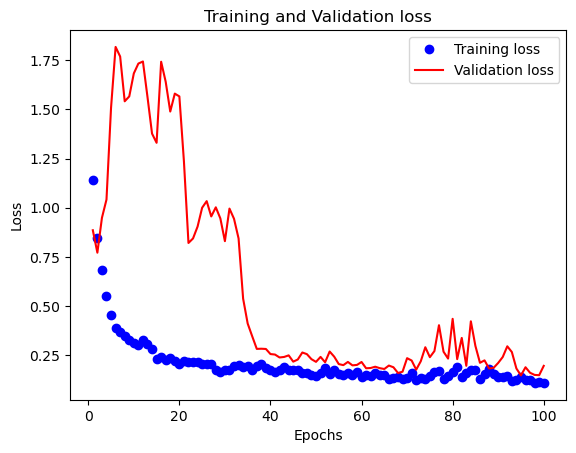

In [17]:
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation loss')
plt.legend()

plt.show()

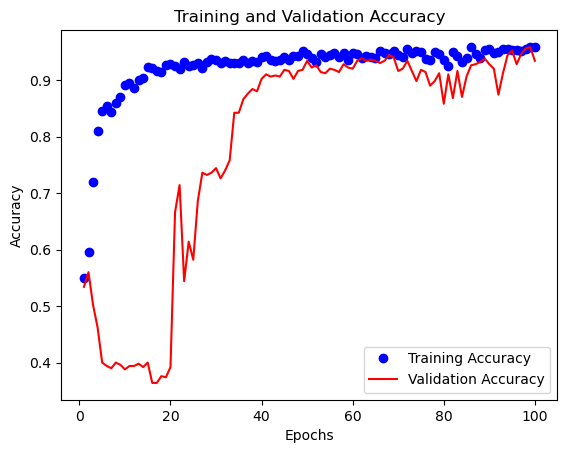

In [15]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(epochs, acc, 'bo', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.show()

# Conclusion
In this mini project, I tried to explain how deep convolutional neural network can be used to classify timeseries data. 1D convnet offer a fast and cheap alternative to a recurrent network on a word-level sentiment classification task. There are other classical methods of modeling timeseries data such as tree-based methods RandomForest and Gradient Boosting.